# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 13     |  |
| :-------------|:-------------|
| Isha Schneiders| 6384838 |
| Laura Otto| 6488463 |
| Max van Spaendonck| 6579353 |
| Planning Groep: 13     |Tijdstip / Tijdspanne  |
|---|---|
| sanity check 1 | 11.15- |
| sanity check 2 | 11.30- |
| sanity check 3 | 12.15 |
| ontwerpen|13.45-14.45|
| bouwen en meten |14.45-16.30|
| opruimen/tijd over | 16.30-17.30 |
| Pauze 1| 12.30-13.30 |


## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="schets_plaat.jpg" alt="schets student 1" width="400"/>

In [1]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
import numpy as np

def vlakkeplaat(epsilon,L,B,d):
    '''
    epsilon = permitiviteit medium
    L = lengte in m
    B = breedte in m
    d = afstand tussen platen in m
    '''
    C = epsilon*B*L/d 
    return C

def V_out(C,V_in_amplitude,freq,R):
    return C*V_in_amplitude*2*np.pi*freq*R
# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

def C_gemeten(V_out,freq,R,V_in):
    return V_out/(2*np.pi*freq*R*V_in)

In [2]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.
epsilon_0=8.854e-12 #F/m 
epsilon_r=3 #voor papier is het ongeveer 3 keer zo veel als voor vacuum   
epsilon_karton=epsilon_r*epsilon_0
L= 10e-2 #m
B= 10e-2 #m
d= 1e-3 #m
#C = [functieNaam(2.0), functieNaam(4.7),functieNaam(1.2)]
C_v=vlakkeplaat(epsilon_karton,L,B,d)
print(f"Berekende capaciteit plaatcondensator groep 13 is {C_v:.1e} F")

V_out_amp=V_out(C_v,8,100e3,1000)
print("berkenende V_out_amplitude is %.2f V"%V_out_amp)

C_out=C_gemeten(0.7,100e3,1000,8)
print("gemeten capaciteit van de ocndensator is %e F"%C_out)



Berekende capaciteit plaatcondensator groep 13 is 2.7e-10 F
berkenende V_out_amplitude is 1.34 V
gemeten capaciteit van de ocndensator is 1.392606e-10 F


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](meting_plaat_condensator.jpeg)
![scope meting 2](opsteling_plaat_condensator.jpeg)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage(amplitude) | Gemeten Voltage(amplitude) | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 13| 270 pF | 1.34  V| 0.7 V |139 pF| 

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
<img src="schets_schuif.jpg" alt="schets student 1" width="400"/>
<img src="schets_druk.jpg" alt="schets student 1" width="400"/>
<img src="schets_luchtvochtigheid.jpg" alt="schets student 1" width="400"/>

## Opdracht 3: Welke sensor gaan jullie maken?

Pas deze tekst aan: Wij gaan een sensor maken die gewicht meet.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
<img src="goede_schets_schuif.jpg" alt="schets student 1" width="400"/>

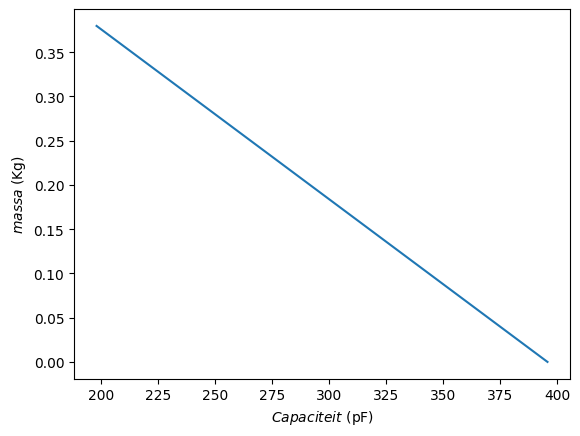

min capaciteit is 197.886900 pF
max capaciteit is 395.773800 pF
max massa is op basis van simulatie 0.380 kg


In [3]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.
import matplotlib.pyplot as plt

g=9.812 #m/s^2 valversnelling
k=50 #N/m veerconstante van onze veer geschat op 0.5 N/cm
L_0=14.9e-2 #begin lengte in cm
L=np.linspace(L_0,0.5*L_0) #lengte neemt af als resultaat van het gewicht dat er aan hangt van L_0 tot een vierde van L_0
B=10e-2 #breede van de plaat blijf gelijk (10cm)
epsilon_r=3
epsilon_karton=epsilon_r*epsilon_0 #epsilpon_r= ongveer 3 voor karton
d= 1e-3 #afstand tussen de platen (1mm)
C_schuif=vlakkeplaat(epsilon_karton,L,B,d) #de capaciteit

def massa(k,g,L_0,C,d,epsilon,B):
    #de massa van het object dat hangt(komt van k*x=m*g, met x=L_0-C*d/epsilon*B), x komt van de formule C=epsilon*B*(L_0-x)/d
    '''
    k=veerconstante in N/m
    g=valversnelling in m/s^2
    C=capaciteit in F
    d=afstand tussen platen in m
    epsilon=permitiviteit in F/m
    B = plaatbreedte in m
    '''
    return (k/g)*(L_0-C*d/(epsilon*B))
m=massa(k,g,L_0,C_schuif,d,epsilon_karton,B)

plt.figure()
plt.plot(C_schuif*1e12,m)
plt.ylabel("$massa$ (Kg)")
plt.xlabel("$Capaciteit$ (pF)")
plt.show()

C_min=vlakkeplaat(epsilon_karton,0.5*L_0,B,d)*1e12
C_max=vlakkeplaat(epsilon_karton,L_0,B,d)*1e12
print("min capaciteit is %f pF"%C_min)
print("max capaciteit is %f pF"%C_max)
print("max massa is op basis van simulatie %.3f kg"%max(m))

## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (V)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 197 | 1.848 |
| gemiddelde capaciteit| 296 | 1.992 |
| maximale capaciteit| 395| 2.354 |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
<img src="opstelling_zondr_iteratie.jpg" alt="schets student 1" width="400"/>


## Opdracht 7: Plot de kalibratiegrafiek.

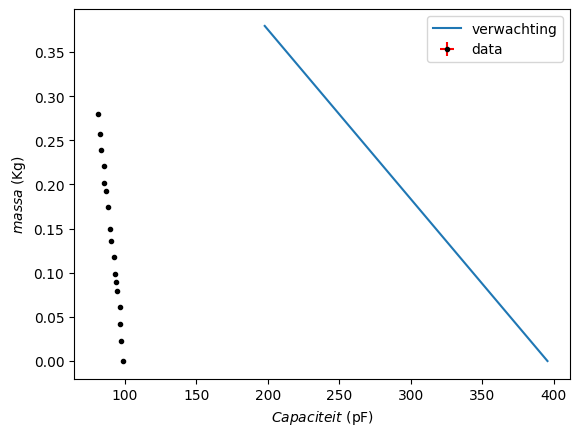

In [4]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.
from scipy.optimize import curve_fit

m_meting=np.array([0,22.4,41.9,61.3,79.8,89.5,98.7,117.7,
    135.6,150,174.5,192.9,201.7,221.2,239.3,257.4,279.8])*1e-3
capaciteit=np.array([98.8,97.5,96.3,96.3,94.5,93.9,92.9,92.3,90.1
                     ,89.9,87.9,86.5,85.5,85.2,83,82.5,81.2]) #pF
c_err=1 #pF
m_err=1e-3 #0.1 gr

plt.figure()
plt.plot(C_schuif*1e12,m,label="verwachting")
plt.errorbar(capaciteit,m_meting,yerr=m_err,xerr=c_err,ecolor="red",fmt="k.",label="data")
plt.ylabel("$massa$ (Kg)")
plt.xlabel("$Capaciteit$ (pF)")
plt.legend()
plt.show()

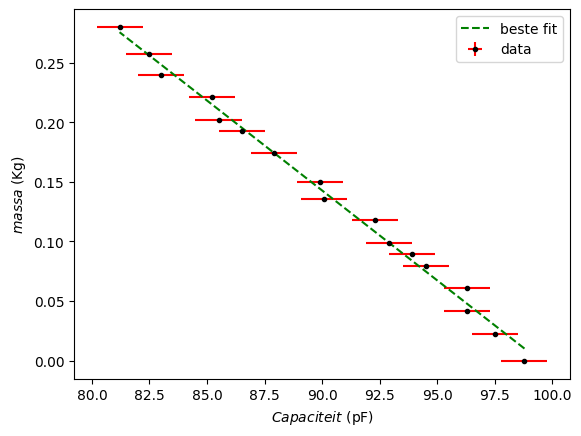

In [5]:

def lin_func(x,a,b):
    y=a*x+b
    return y
val,cov=curve_fit(lin_func,capaciteit,m_meting)
x_plot=np.linspace(min(capaciteit),max(capaciteit),1000)

plt.figure()
plt.errorbar(capaciteit,m_meting,yerr=m_err,xerr=c_err,ecolor="red",fmt="k.",label="data")
plt.plot(capaciteit,lin_func(capaciteit,*val),"g--",label="beste fit")
plt.ylabel("$massa$ (Kg)")
plt.xlabel("$Capaciteit$ (pF)")
plt.legend()
plt.show()

## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* kleinere en consistentere plaat afstand
* geen verschuifving van link naar recht door een rail toe te voegen

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
<img src="opstelling_metiteratie.jpg" alt="schets student 1" width="400"/>

De gevoeligheid a is bepaald op a = -0.0145 ± 0.0003 kg/pF en b is bepaald op b = 1.45 ± 0.02 kg 


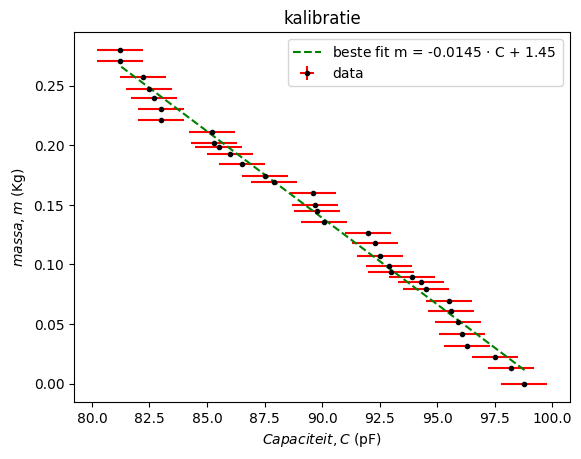

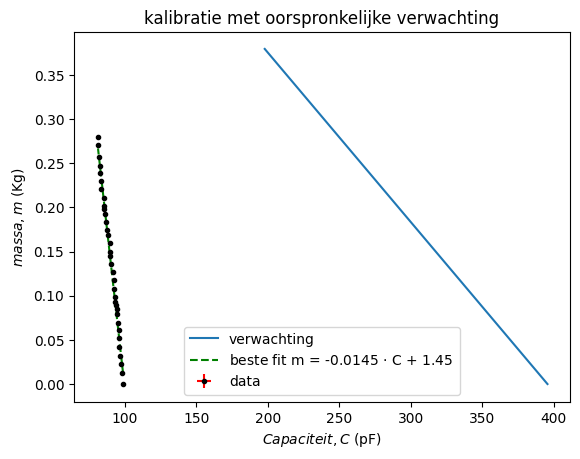

De onzekerheid in onze sensor wordt weergeven door:


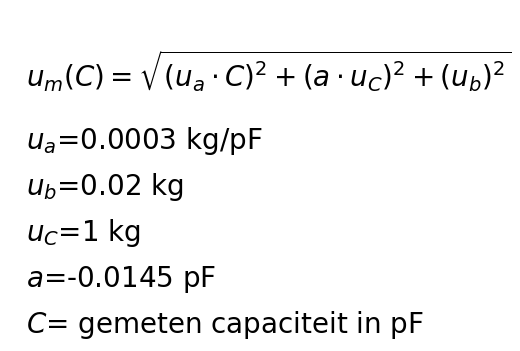

In [6]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij
#data
m_meting=np.array([0,12.9,22.4,31.9,41.9,51.6,61.3,69.6,79.8,85.5,89.5,93.3,98.7,107.4,117.7,126.6,
    135.6,144.5,150,159.9,169.2,174.5,184,192.9,198.6,201.7,211.2,221.2,230.3,239.3,247.5,257.4,270.6,279.8])*1e-3
capaciteit=np.array([98.8,98.2,97.5,96.3,96.1,95.9,95.6,95.5,94.5,94.3,93.9,93.0,92.9,92.5,92.3,92.0,90.1
                     ,89.8,89.7,89.6,87.9,87.5,86.5,86.0,85.5,85.3,85.2,83.0,83,82.7,82.5,82.2,81.2,81.2]) #pF
c_err=1 #onzekerhied in C pF
m_err=1e-3 #onzekerhied in m 0.1 gr
val,cov=curve_fit(lin_func,capaciteit,m_meting) #fit
x_plot=np.linspace(min(capaciteit),max(capaciteit),1000) #om de fit mee te plotten
a,b=val #waarden voor a en b
u_a,u_b=np.sqrt(np.diag(cov)) #onzekerheid in a en b
print(f"De gevoeligheid a is bepaald op a = {a:.4f} \u00B1 {u_a:.4f} kg/pF en b is bepaald op b = {b:.2f} \u00B1 {u_b:.2f} kg ")

#plotten kalibratie zonder verwachting
plt.figure()
plt.title("kalibratie")
plt.errorbar(capaciteit,m_meting,yerr=m_err,xerr=c_err,ecolor="red",fmt="k.",label="data")
plt.plot(capaciteit,lin_func(capaciteit,*val),"g--",label=r"beste fit m = %.4f $\cdot$ C + %.2f "%(a,b))
plt.ylabel("$massa, m$ (Kg)")
plt.xlabel("$Capaciteit, C$ (pF)")
plt.legend()
plt.show()

#plotten kalibratie met verwachting
plt.figure()
plt.title("kalibratie met oorspronkelijke verwachting")
plt.plot(C_schuif*1e12,m,label="verwachting")
plt.errorbar(capaciteit,m_meting,yerr=m_err,xerr=c_err,ecolor="red",fmt="k.",label="data")
plt.plot(capaciteit,lin_func(capaciteit,*val),"g--",label=r"beste fit m = %.4f $\cdot$ C + %.2f "%(a,b))
plt.ylabel("$massa, m$ (Kg)")
plt.xlabel("$Capaciteit, C$ (pF)")
plt.legend()
plt.show()

#berkenen onzekerheid van onze sensor met m= a* C + b:
#partiele afgeleide voor calculus approach:
#----_dm_da=Capaciteit (C)
#-----dm_dC=a
#-----dm_db=1
#-----u_m=np.sqrt((dm_da*u_a)**2 + (dm_dC*c_err)**2 + (dm_db*u_b)**2)=np.sqrt((C*u_a)**2 + (a*c_err)**2 + (u_b)**2)

def onzekerheid_massa(C):
    u_m=np.sqrt((C*u_a)**2 + (a*c_err)**2 + (u_b)**2) #onzekerheid in m via calculus approach
    return u_m

print(r"De onzekerheid in onze sensor wordt weergeven door:")
plt.figure(figsize=(2,2))
plt.text(0.1, 0.5, r"$u_m(C) = \sqrt{(u_a \cdot C)^2 + (a\cdot u_C)^2 + (u_b)^2}$", fontsize=20)
plt.text(0.1, 0.1, r"$u_a$=%.4f kg/pF"%(u_a), fontsize=20)
plt.text(0.1, -0.2, r"$u_b$=%.2f kg"%(u_b), fontsize=20)
plt.text(0.1, -0.5, r"$u_C$=%.0f kg"%(c_err), fontsize=20)
plt.text(0.1, -0.8, r"$a$=%.4f pF"%(a), fontsize=20)
plt.text(0.1, -1.1, "$C$= gemeten capaciteit in pF", fontsize=20)
plt.axis('off')
plt.show()

## Opdracht 10: Vul hieronder de conclusie in.

Uit de resultaten blijkt dat de sensor geschikt is om gewicht te meten van 0 tot 300 gram. In de grafiek is te zien dat de metingen stapgewijs hetzelfde patroon laat zien, er wordt verwacht dat dit komt door de wrijvingsweerstand tussen de platen waardoor de platen schoksgewijs schuiven. Voor vervolgonderzoek kan er rekening gehouden worden met de wrijvingsweerstand van de opstelling door middel van wielen en katrollen. In de opstelling is nu elektrisch contact gemaakt door een stuk metaal op de platen te tapen, maar in toekomstig onderzoek is het beter om elektrisch contact te maken via soldeer.

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

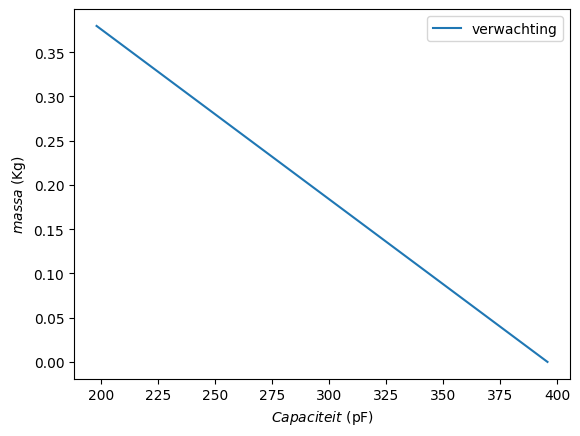

min capaciteit is 197.886900 pF
max capaciteit is 395.773800 pF
max massa is op basis van simulatie 0.380 kg


In [7]:
#Plot hier de verwachte ontwerpgrafiek van jullie sensoren.
import matplotlib.pyplot as plt

#aannames voor de schattting
g=9.812 #m/s^2 valversnelling
k=50 #N/m veerconstante van onze veer geschat op 0.5 N/cm
L_0=14.9e-2 #begin lengte in cm
L=np.linspace(L_0,0.5*L_0) #lengte neemt af als resultaat van het gewicht dat er aan hangt van L_0 tot een vierde van L_0
B=10e-2 #breede van de plaat blijf gelijk (10cm)
epsilon_r=3
epsilon_karton=epsilon_r*epsilon_0 #epsilpon_r= ongveer 3 voor karton
d= 1e-3 #afstand tussen de platen (1mm)
C_schuif=vlakkeplaat(epsilon_karton,L,B,d) #de capaciteit

def massa(k,g,L_0,C,d,epsilon,B):
    #de massa van het object dat hangt(komt van k*x=m*g, met x=L_0-C*d/epsilon*B), x komt van de formule C=epsilon*B*(L_0-x)/d
    '''
    k=veerconstante in N/m
    g=valversnelling in m/s^2
    C=capaciteit in F
    d=afstand tussen platen in m
    epsilon=permitiviteit in F/m
    B = plaatbreedte in m
    '''
    return (k/g)*(L_0-C*d/(epsilon*B))
m=massa(k,g,L_0,C_schuif,d,epsilon_karton,B)

#plotten
plt.figure()
plt.plot(C_schuif*1e12,m,label="verwachting")
plt.ylabel("$massa$ (Kg)")
plt.xlabel("$Capaciteit$ (pF)")
plt.legend()
plt.show()

C_min=vlakkeplaat(epsilon_karton,0.5*L_0,B,d)*1e12
C_max=vlakkeplaat(epsilon_karton,L_0,B,d)*1e12
print("min capaciteit is %f pF"%C_min)
print("max capaciteit is %f pF"%C_max)
print("max massa is op basis van simulatie %.3f kg"%max(m))

Doot middel van deze opstellingen meten wij het gewocht dat aan het touwtje hangt. Dit doen we door het verkleinen van het contactoppervlakte van de condensator.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
<img src="goede_schets_schuif.jpg" alt="schets student 1" width="400"/>

#### Voeg hier een foto van je uiteindelijke sensor in.
<img src="opstelling_metiteratie.jpg" alt="schets student 1" width="400"/>

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](meting_plaat_condensator.jpeg)
![scope meting 2](opsteling_plaat_condensator.jpeg)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage(amplitude) | Gemeten Voltage(amplitude) | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 13| 270 pF | 1.34  V| 0.7 V |139 pF| 

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (V)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 197 | 1.848 |
| gemiddelde capaciteit| 296 | 1.992 |
| maximale capaciteit| 395| 2.354 |

In [8]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
import numpy as np

def vlakkeplaat(epsilon,L,B,d):
    '''
    epsilon = permitiviteit medium
    L = lengte in m
    B = breedte in m
    d = afstand tussen platen in m
    '''
    C = epsilon*B*L/d 
    return C

def V_out(C,V_in_amplitude,freq,R):
    return C*V_in_amplitude*2*np.pi*freq*R
# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

def C_gemeten(V_out,freq,R,V_in):
    return V_out/(2*np.pi*freq*R*V_in)

In [9]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.
epsilon_0=8.854e-12 #F/m 
epsilon_r=3 #voor papier is het ongeveer 3 keer zo veel als voor vacuum   
epsilon_karton=epsilon_r*epsilon_0
L= 10e-2 #m
B= 10e-2 #m
d= 1e-3 #m
#C = [functieNaam(2.0), functieNaam(4.7),functieNaam(1.2)]
C_v=vlakkeplaat(epsilon_karton,L,B,d)
print(f"Berekende capaciteit plaatcondensator groep 13 is {C_v:.1e} F")

V_out_amp=V_out(C_v,8,100e3,1000)
print("berkenende V_out_amplitude is %.2f V"%V_out_amp)

C_out=C_gemeten(0.7,100e3,1000,8)
print("gemeten capaciteit van de ocndensator is %e F"%C_out)



Berekende capaciteit plaatcondensator groep 13 is 2.7e-10 F
berkenende V_out_amplitude is 1.34 V
gemeten capaciteit van de ocndensator is 1.392606e-10 F


kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.

De gevoeligheid a is bepaald op a = -0.0145 ± 0.0003 kg/pF en b is bepaald op b = 1.45 ± 0.02 kg 


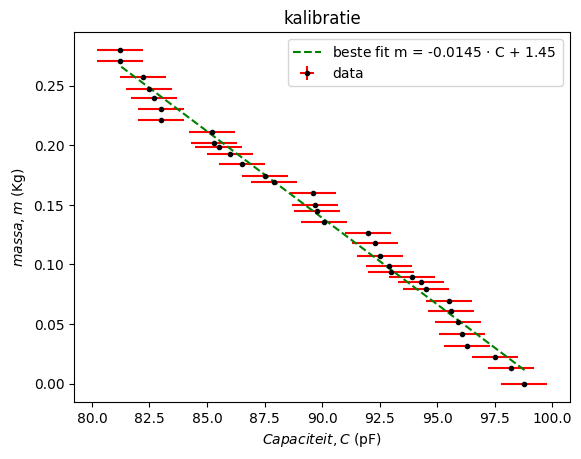

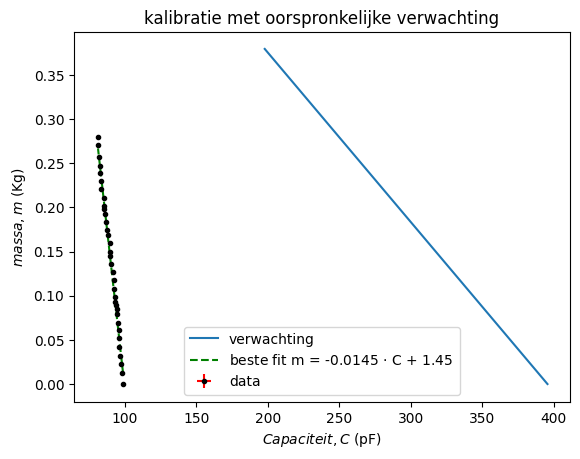

De onzekerheid in onze sensor wordt weergeven door:


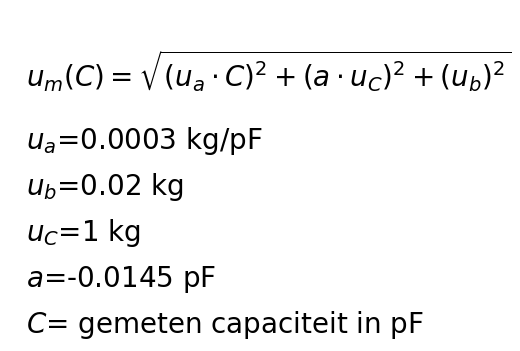

In [10]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij
#data
m_meting=np.array([0,12.9,22.4,31.9,41.9,51.6,61.3,69.6,79.8,85.5,89.5,93.3,98.7,107.4,117.7,126.6,
    135.6,144.5,150,159.9,169.2,174.5,184,192.9,198.6,201.7,211.2,221.2,230.3,239.3,247.5,257.4,270.6,279.8])*1e-3
capaciteit=np.array([98.8,98.2,97.5,96.3,96.1,95.9,95.6,95.5,94.5,94.3,93.9,93.0,92.9,92.5,92.3,92.0,90.1
                     ,89.8,89.7,89.6,87.9,87.5,86.5,86.0,85.5,85.3,85.2,83.0,83,82.7,82.5,82.2,81.2,81.2]) #pF
c_err=1 #onzekerhied in C pF
m_err=1e-3 #onzekerhied in m 0.1 gr
val,cov=curve_fit(lin_func,capaciteit,m_meting) #fit
x_plot=np.linspace(min(capaciteit),max(capaciteit),1000) #om de fit mee te plotten
a,b=val #waarden voor a en b
u_a,u_b=np.sqrt(np.diag(cov)) #onzekerheid in a en b
print(f"De gevoeligheid a is bepaald op a = {a:.4f} \u00B1 {u_a:.4f} kg/pF en b is bepaald op b = {b:.2f} \u00B1 {u_b:.2f} kg ")

#plotten kalibratie zonder verwachting
plt.figure()
plt.title("kalibratie")
plt.errorbar(capaciteit,m_meting,yerr=m_err,xerr=c_err,ecolor="red",fmt="k.",label="data")
plt.plot(capaciteit,lin_func(capaciteit,*val),"g--",label=r"beste fit m = %.4f $\cdot$ C + %.2f "%(a,b))
plt.ylabel("$massa, m$ (Kg)")
plt.xlabel("$Capaciteit, C$ (pF)")
plt.legend()
plt.show()

#plotten kalibratie met verwachting
plt.figure()
plt.title("kalibratie met oorspronkelijke verwachting")
plt.plot(C_schuif*1e12,m,label="verwachting")
plt.errorbar(capaciteit,m_meting,yerr=m_err,xerr=c_err,ecolor="red",fmt="k.",label="data")
plt.plot(capaciteit,lin_func(capaciteit,*val),"g--",label=r"beste fit m = %.4f $\cdot$ C + %.2f "%(a,b))
plt.ylabel("$massa, m$ (Kg)")
plt.xlabel("$Capaciteit, C$ (pF)")
plt.legend()
plt.show()

#berkenen onzekerheid van onze sensor met m= a* C + b:
#partiele afgeleide voor calculus approach:
#----_dm_da=Capaciteit (C)
#-----dm_dC=a
#-----dm_db=1
#-----u_m=np.sqrt((dm_da*u_a)**2 + (dm_dC*c_err)**2 + (dm_db*u_b)**2)=np.sqrt((C*u_a)**2 + (a*c_err)**2 + (u_b)**2)

def onzekerheid_massa(C):
    u_m=np.sqrt((C*u_a)**2 + (a*c_err)**2 + (u_b)**2) #onzekerheid in m via calculus approach
    return u_m

print(r"De onzekerheid in onze sensor wordt weergeven door:")
plt.figure(figsize=(2,2))
plt.text(0.1, 0.5, r"$u_m(C) = \sqrt{(u_a \cdot C)^2 + (a\cdot u_C)^2 + (u_b)^2}$", fontsize=20)
plt.text(0.1, 0.1, r"$u_a$=%.4f kg/pF"%(u_a), fontsize=20)
plt.text(0.1, -0.2, r"$u_b$=%.2f kg"%(u_b), fontsize=20)
plt.text(0.1, -0.5, r"$u_C$=%.0f kg"%(c_err), fontsize=20)
plt.text(0.1, -0.8, r"$a$=%.4f pF"%(a), fontsize=20)
plt.text(0.1, -1.1, "$C$= gemeten capaciteit in pF", fontsize=20)
plt.axis('off')
plt.show()

Uit de resultaten blijkt dat de sensor geschikt is om gewicht te meten van 0 tot 300 gram. In de grafiek is te zien dat de metingen stapgewijs hetzelfde patroon laat zien, er wordt verwacht dat dit komt door de wrijvingsweerstand tussen de platen waardoor de platen schoksgewijs schuiven. Voor vervolgonderzoek kan er rekening gehouden worden met de wrijvingsweerstand van de opstelling door middel van wielen en katrollen. In de opstelling is nu elektrisch contact gemaakt door een stuk metaal op de platen te tapen, maar in toekomstig onderzoek is het beter om elektrisch contact te maken via soldeer.